# Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import vrplib
import os
import pulp

print(vrplib.__version__ if hasattr(vrplib, "__version__") else "vrplib ok", pulp.__version__)

OUTPUT_PATH_figures = "/Users/chamika/Desktop/git/machine_learning/Question_3/outputs/figures/"
DATA_PATH_raw    = "/Users/chamika/Desktop/git/machine_learning/Question_3/data/raw/"
DATA_PATH_processed    = "/Users/chamika/Desktop/git/machine_learning/Question_3/data/processed/"

vrplib ok 3.3.2


# 3.2 Data Preparation and Problem Analysis

## 3.2.1 Data Acquisition — CVRPLIB Benchmark Instances

Download the three Augerat Set A instances (A-n32-k5, A-n54-k7, A-n80-k10)
from a mirror of the canonical CVRPLIB files, and inspect the smallest
instance to confirm the data structure and best-known cost.

In [17]:
# Cell 1: Download benchmark instances (Augerat Set A) from a GitHub mirror
# Note: vrplib >= 2.0 removed its download module (CVRPLIB moved sites),
# so instances are fetched directly and read locally with vrplib.
import urllib.request

os.makedirs(DATA_PATH_raw, exist_ok=True)
os.makedirs(DATA_PATH_processed, exist_ok=True)
os.makedirs(OUTPUT_PATH_figures, exist_ok=True)

INSTANCES = ["A-n32-k5", "A-n54-k7", "A-n80-k10"]
MIRROR = "https://raw.githubusercontent.com/giulianoxt/vehicle-routing-aco/master/augerat-a/"

for name in INSTANCES:
    path = f"{DATA_PATH_raw}{name}.vrp"
    if not os.path.exists(path):                      # download once, then frozen
        urllib.request.urlretrieve(f"{MIRROR}{name}.vrp", path)
        print(f"Downloaded {name}.vrp")
    else:
        print(f"{name}.vrp already present — skipping")

def best_known_cost(inst):
    """Parse the best-known/optimal cost from the instance COMMENT line."""
    import re
    m = re.search(r"(?:Optimal|Best) value:\s*(\d+)", inst["comment"])
    return int(m.group(1)) if m else None

# Inspect the smallest instance to confirm structure
inst = vrplib.read_instance(f"{DATA_PATH_raw}A-n32-k5.vrp")

print("\nKeys:", list(inst.keys()))
print("Comment:", inst["comment"])
print("Dimension (nodes incl. depot):", inst["dimension"])
print("Vehicle capacity:", inst["capacity"])
print("Edge weight type:", inst.get("edge_weight_type"))
print("First 5 coordinates:\n", inst["node_coord"][:5])
print("First 5 demands:", inst["demand"][:5])
print("Best-known cost (from comment):", best_known_cost(inst))

A-n32-k5.vrp already present — skipping
A-n54-k7.vrp already present — skipping
A-n80-k10.vrp already present — skipping

Keys: ['name', 'comment', 'type', 'dimension', 'edge_weight_type', 'capacity', 'trucks', 'node_coord', 'demand', 'depot', 'edge_weight']
Comment: (Augerat et al, Min no of trucks: 5, Optimal value: 784)
Dimension (nodes incl. depot): 32
Vehicle capacity: 100
Edge weight type: EUC_2D
First 5 coordinates:
 [[82 76]
 [96 44]
 [50  5]
 [49  8]
 [13  7]]
First 5 demands: [ 0 19 21  6 19]
Best-known cost (from comment): 784


## 3.2.1(Table 3.1) Instance Parameters and Summary Table

Extract the problem parameters (customers, fleet size, capacity, demands)
for all three instances, compute constraint-tightness measures
(⌈D/Q⌉, capacity utilisation), and save the summary as Table 3.1.

In [18]:
# Cell 2: Instance parameters and summary table
rows = []

for name in INSTANCES:
    inst = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")

    demands   = inst["demand"][1:]              # index 0 is the depot (demand 0)
    Q         = inst["capacity"]
    K         = int(inst["trucks"])             # explicit TRUCKS field in these files
    total_dem = demands.sum()

    rows.append({
        "Instance":             name,
        "Customers (n)":        inst["dimension"] - 1,
        "Vehicles (K)":         K,
        "Capacity (Q)":         Q,
        "Total demand":         total_dem,
        "Min vehicles ceil(D/Q)": int(np.ceil(total_dem / Q)),
        "Capacity utilisation": f"{total_dem / (K * Q):.1%}",
        "Demand min/mean/max":  f"{demands.min()}/{demands.mean():.1f}/{demands.max()}",
        "Best-known cost":      best_known_cost(inst),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(f"{DATA_PATH_processed}q3_instance_summary.csv", index=False)

 Instance  Customers (n)  Vehicles (K)  Capacity (Q)  Total demand  Min vehicles ceil(D/Q) Capacity utilisation Demand min/mean/max  Best-known cost
 A-n32-k5             31             5           100           410                       5                82.0%           1/13.2/24              784
 A-n54-k7             53             7           100           669                       7                95.6%           2/12.6/36             1167
A-n80-k10             79            10           100           942                      10                94.2%           1/11.9/26             1764


## 3.2.2 Distance Matrix Construction and Verification

Compute rounded Euclidean distance matrices from node coordinates (the CVRPLIB
convention under which best-known costs are defined) and verify them
element-for-element against vrplib's independently computed matrices.

In [19]:
# # Cell 3: Compute Euclidean distance matrices and verify against vrplib
def euclidean_matrix(coords, rounded=True):
    """Pairwise Euclidean distances; rounded to nearest integer per
    the CVRPLIB convention under which best-known costs are defined."""
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt((diff ** 2).sum(axis=-1))
    return np.round(D).astype(int) if rounded else D

dist_matrices = {}
for name in INSTANCES:
    inst  = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    D_own = euclidean_matrix(inst["node_coord"])
    D_lib = np.round(inst["edge_weight"]).astype(int)   # round vrplib's unrounded EUC_2D

    match = np.array_equal(D_own, D_lib)
    print(f"{name}: matrix {D_own.shape}, symmetric={np.allclose(D_own, D_own.T)}, "
          f"zero diagonal={np.all(np.diag(D_own) == 0)}, matches vrplib={match}")

    dist_matrices[name] = D_own
    np.save(f"{DATA_PATH_processed}{name}_dist.npy", D_own)

print("\nSaved distance matrices to data/processed/")

A-n32-k5: matrix (32, 32), symmetric=True, zero diagonal=True, matches vrplib=True
A-n54-k7: matrix (54, 54), symmetric=True, zero diagonal=True, matches vrplib=True
A-n80-k10: matrix (80, 80), symmetric=True, zero diagonal=True, matches vrplib=True

Saved distance matrices to data/processed/


## 3.2.1(Figure 3.1) Instance Geometry Visualisation (Figure 3.1)

Plot the spatial layout of each instance — depot position and customer
locations, with marker area proportional to demand.

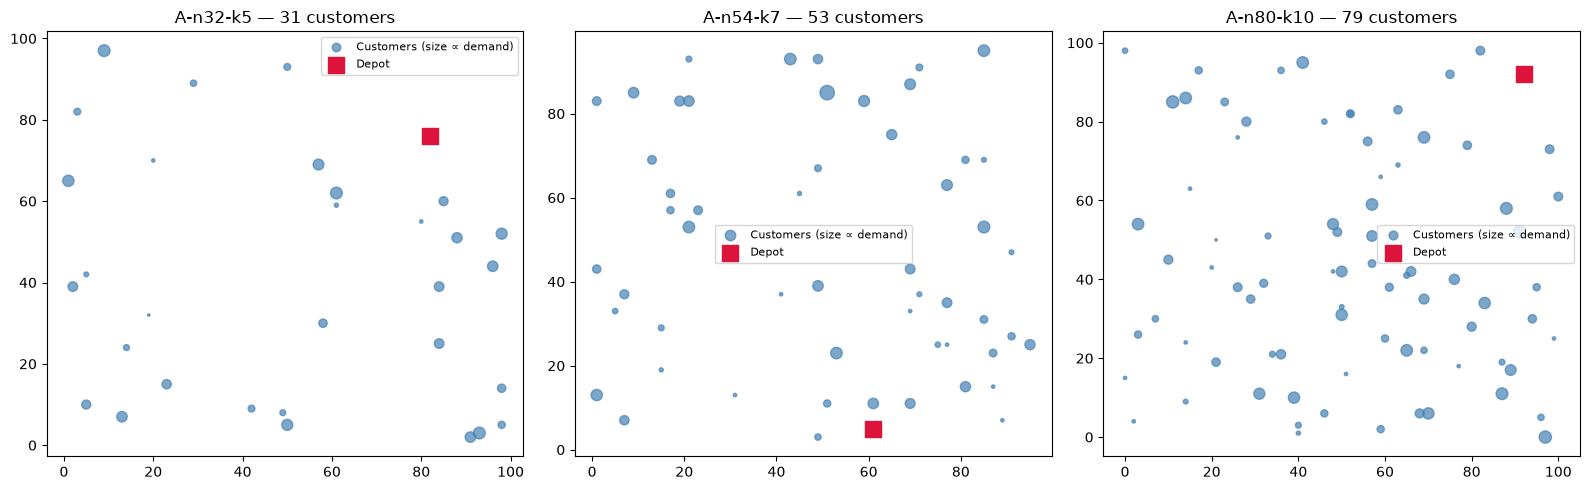

In [20]:
# Cell 4: Visualise the three instances — depot, customers, demand sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, INSTANCES):
    inst   = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    coords = inst["node_coord"]
    dem    = inst["demand"]

    ax.scatter(coords[1:, 0], coords[1:, 1], s=dem[1:] * 3,
               c="steelblue", alpha=0.7, label="Customers (size ∝ demand)")
    ax.scatter(*coords[0], marker="s", s=120, c="crimson", label="Depot", zorder=3)
    ax.set_title(f"{name} — {inst['dimension'] - 1} customers")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH_figures}q3_fig1_instances.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.2.3 Complexity Analysis

Quantify problem difficulty per instance: factorial search-space size
(giant-tour orderings) and MIP model dimensions (binary arc variables,
MTZ variables and constraints).

In [21]:
# Cell 5: Search space size and MIP model dimensions per instance
from math import factorial, log10

print(f"{'Instance':<12}{'n':>4}{'log10(n!)':>12}{'x_ij vars':>11}"
      f"{'u_i vars':>10}{'MTZ constrs':>13}")
for name in INSTANCES:
    inst    = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    n_nodes = inst["dimension"]
    n_cust  = n_nodes - 1

    log_space = log10(factorial(n_cust))       # giant-tour orderings
    n_x       = n_nodes * (n_nodes - 1)        # binary arc variables
    n_u       = n_cust                         # continuous MTZ variables
    n_mtz     = n_cust * (n_cust - 1)          # MTZ inequality constraints

    print(f"{name:<12}{n_cust:>4}{log_space:>12.1f}{n_x:>11}{n_u:>10}{n_mtz:>13}")

Instance       n   log10(n!)  x_ij vars  u_i vars  MTZ constrs
A-n32-k5      31        33.9        992        31          930
A-n54-k7      53        69.6       2862        53         2756
A-n80-k10     79       117.0       6320        79         6162


# 3.3 Genetic Algorithm Design and Implementation

## Chromosome decoding (split procedure)

In [22]:
# Cell 6: Split decoder — convert a giant-tour chromosome into feasible routes
def split_decode(chromosome, dist, demand, capacity):
    """
    chromosome: list of customer indices (1..n), a permutation, no depot.
    dist:       (n+1)x(n+1) distance matrix, index 0 = depot.
    demand:     array of length n+1, demand[0] = 0 (depot).
    capacity:   vehicle capacity Q.

    Returns: (routes, total_distance)
      routes = list of routes, each route a list of customer indices
               (depot implied at both ends)
    """
    routes = []
    current_route = []
    current_load = 0

    for cust in chromosome:
        d = demand[cust]
        if current_load + d > capacity:
            # close current route, start a new one
            routes.append(current_route)
            current_route = [cust]
            current_load = d
        else:
            current_route.append(cust)
            current_load += d

    if current_route:
        routes.append(current_route)

    # Total distance: depot -> route -> depot, summed over all routes
    total_distance = 0
    for route in routes:
        prev = 0                          # depot
        for cust in route:
            total_distance += dist[prev, cust]
            prev = cust
        total_distance += dist[prev, 0]    # return to depot

    return routes, total_distance


# Quick sanity check on A-n32-k5 using its own customer order (not yet optimised)
inst = vrplib.read_instance(f"{DATA_PATH_raw}A-n32-k5.vrp")
demand = inst["demand"]
D = dist_matrices["A-n32-k5"]
trivial_chromosome = list(range(1, inst["dimension"]))   # customers 1..31, natural order

routes, dist_total = split_decode(trivial_chromosome, D, demand, inst["capacity"])
print(f"Number of routes from trivial ordering: {len(routes)}  (K = {inst['trucks']})")
print(f"Total distance: {dist_total}  (best-known: {best_known_cost(inst)})")
print("Route lengths (customers per route):", [len(r) for r in routes])

Number of routes from trivial ordering: 5  (K = 5)
Total distance: 2082  (best-known: 784)
Route lengths (customers per route): [7, 7, 6, 7, 4]


## Fitness function with fleet-size penalty

In [23]:
# Cell 7: Fitness function — distance + penalty for wrong number of routes
def fitness(chromosome, dist, demand, capacity, K, penalty_weight=1000):
    """Lower is better. Penalises deviation from the target fleet size K,
    since the split decoder does not enforce K directly."""
    routes, dist_total = split_decode(chromosome, dist, demand, capacity)
    route_penalty = penalty_weight * abs(len(routes) - K)
    return dist_total + route_penalty, routes, dist_total

# Sanity check: penalty should be large here, since trivial ordering ≠ 5 routes
fit, routes, raw_dist = fitness(trivial_chromosome, D, demand, inst["capacity"], inst["trucks"])
print(f"Fitness: {fit}  |  Raw distance: {raw_dist}  |  Routes used: {len(routes)}  |  Target K: {inst['trucks']}")

Fitness: 2082  |  Raw distance: 2082  |  Routes used: 5  |  Target K: 5


## Random Population Initialization

In [24]:
# Cell 8: Population initialisation — random permutations of customers
def initialize_population(pop_size, n_customers, rng):
    """Each individual is a random permutation of customer indices 1..n_customers."""
    population = []
    for _ in range(pop_size):
        chromosome = list(rng.permutation(np.arange(1, n_customers + 1)))
        population.append(chromosome)
    return population

# Sanity check on A-n32-k5
rng = np.random.default_rng(seed=42)   # fixed seed for reproducibility
POP_SIZE = 100

pop = initialize_population(POP_SIZE, inst["dimension"] - 1, rng)

print(f"Population size: {len(pop)}")
print(f"Chromosome length: {len(pop[0])}  (expected: {inst['dimension'] - 1})")
print(f"First chromosome (first 10 genes): {pop[0][:10]}")
print(f"Is a valid permutation: {sorted(pop[0]) == list(range(1, inst['dimension']))}")

# Evaluate the whole initial population to see the fitness spread
fits = [fitness(chrom, D, demand, inst["capacity"], inst["trucks"])[0] for chrom in pop]
route_counts = [fitness(chrom, D, demand, inst["capacity"], inst["trucks"])[1] for chrom in pop]
n_routes = [len(r) for r in route_counts]

print(f"\nInitial population fitness — min: {min(fits)}, mean: {np.mean(fits):.1f}, max: {max(fits)}")
print(f"Route counts used — min: {min(n_routes)}, mean: {np.mean(n_routes):.2f}, max: {max(n_routes)} (target K={inst['trucks']})")
print(f"Individuals with exactly K={inst['trucks']} routes: {sum(1 for r in n_routes if r == inst['trucks'])}/{POP_SIZE}")

Population size: 100
Chromosome length: 31  (expected: 31)
First chromosome (first 10 genes): [np.int64(31), np.int64(17), np.int64(8), np.int64(27), np.int64(26), np.int64(24), np.int64(6), np.int64(23), np.int64(28), np.int64(11)]
Is a valid permutation: True

Initial population fitness — min: 1770, mean: 2117.3, max: 2454
Route counts used — min: 5, mean: 5.00, max: 5 (target K=5)
Individuals with exactly K=5 routes: 100/100


In [25]:
# Cell 8b: Check route-count spread on the two tighter instances
for name in ["A-n54-k7", "A-n80-k10"]:
    inst_i   = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    demand_i = inst_i["demand"]
    D_i      = dist_matrices[name]
    K_i      = inst_i["trucks"]

    pop_i = initialize_population(POP_SIZE, inst_i["dimension"] - 1, rng)
    results = [fitness(c, D_i, demand_i, inst_i["capacity"], K_i) for c in pop_i]
    n_routes_i = [len(r[1]) for r in results]
    fits_i     = [r[0] for r in results]

    print(f"{name} (K={K_i}): routes min/mean/max = "
          f"{min(n_routes_i)}/{np.mean(n_routes_i):.2f}/{max(n_routes_i)}, "
          f"exactly-K count = {sum(1 for r in n_routes_i if r == K_i)}/{POP_SIZE}, "
          f"fitness min/mean = {min(fits_i)}/{np.mean(fits_i):.1f}")

A-n54-k7 (K=7): routes min/mean/max = 7/7.84/8, exactly-K count = 16/100, fitness min/mean = 2917/4113.5
A-n80-k10 (K=10): routes min/mean/max = 10/10.75/11, exactly-K count = 25/100, fitness min/mean = 4565/5716.6


## Tournament selection:

In [26]:
# Cell 9: Tournament selection
def tournament_selection(population, fitnesses, tournament_size, rng):
    """Select one parent: sample tournament_size individuals uniformly,
    return the fittest (lowest fitness = best, since we minimise distance)."""
    idx = rng.choice(len(population), size=tournament_size, replace=False)
    best_idx = min(idx, key=lambda i: fitnesses[i])
    return population[best_idx]

# Sanity check on A-n32-k5's initial population
TOURNAMENT_SIZE = 5
fits_only = [fitness(c, D, demand, inst["capacity"], inst["trucks"])[0] for c in pop]

selected = tournament_selection(pop, fits_only, TOURNAMENT_SIZE, rng)
sel_fit = fitness(selected, D, demand, inst["capacity"], inst["trucks"])[0]
print(f"Selected individual fitness: {sel_fit}")
print(f"Population fitness range: {min(fits_only)}–{max(fits_only)}, mean {np.mean(fits_only):.1f}")

# Repeat selection 1000 times to confirm selection pressure:
# selected individuals should skew well below the population mean
selected_fits = [fitness(tournament_selection(pop, fits_only, TOURNAMENT_SIZE, rng),
                          D, demand, inst["capacity"], inst["trucks"])[0]
                  for _ in range(1000)]
print(f"\nOver 1000 selections — mean fitness of selected: {np.mean(selected_fits):.1f} "
      f"(population mean: {np.mean(fits_only):.1f})")

Selected individual fitness: 1985
Population fitness range: 1770–2454, mean 2117.3

Over 1000 selections — mean fitness of selected: 1964.0 (population mean: 2117.3)


## Order Crossover (OX):

In [27]:
# Cell 10: Order Crossover (OX) — standard operator for permutation chromosomes
def order_crossover(parent1, parent2, rng):
    """OX: copy a random slice from parent1 into the child, fill remaining
    positions with parent2's genes in their relative order, skipping genes
    already present. Produces one child; call twice (swap parents) for two."""
    n = len(parent1)
    i, j = sorted(rng.choice(n, size=2, replace=False))

    child = [None] * n
    child[i:j+1] = parent1[i:j+1]
    filled = set(child[i:j+1])

    fill_positions = [k for k in range(n) if child[k] is None]
    fill_genes = [g for g in parent2 if g not in filled]

    for pos, gene in zip(fill_positions, fill_genes):
        child[pos] = gene

    return child

# Sanity check: two children from two random parents
p1, p2 = pop[0], pop[1]
child1 = order_crossover(p1, p2, rng)
child2 = order_crossover(p2, p1, rng)

print("Child 1 valid permutation:", sorted(child1) == list(range(1, len(p1) + 1)))
print("Child 2 valid permutation:", sorted(child2) == list(range(1, len(p1) + 1)))
print(f"Parent 1 fitness: {fitness(p1, D, demand, inst['capacity'], inst['trucks'])[0]}")
print(f"Parent 2 fitness: {fitness(p2, D, demand, inst['capacity'], inst['trucks'])[0]}")
print(f"Child 1 fitness:  {fitness(child1, D, demand, inst['capacity'], inst['trucks'])[0]}")
print(f"Child 2 fitness:  {fitness(child2, D, demand, inst['capacity'], inst['trucks'])[0]}")

Child 1 valid permutation: True
Child 2 valid permutation: True
Parent 1 fitness: 2366
Parent 2 fitness: 2054
Child 1 fitness:  2169
Child 2 fitness:  2157


## Mutation (swap and inversion)

In [28]:
# Cell 11: Mutation operators — swap and inversion
def swap_mutation(chromosome, rng):
    """Swap two randomly chosen genes."""
    child = chromosome.copy()
    i, j = rng.choice(len(child), size=2, replace=False)
    child[i], child[j] = child[j], child[i]
    return child

def inversion_mutation(chromosome, rng):
    """Reverse a randomly chosen contiguous segment."""
    child = chromosome.copy()
    i, j = sorted(rng.choice(len(child), size=2, replace=False))
    child[i:j+1] = child[i:j+1][::-1]
    return child

def mutate(chromosome, mutation_rate, rng):
    """Apply inversion mutation with probability mutation_rate, else swap."""
    if rng.random() < mutation_rate:
        return inversion_mutation(chromosome, rng)
    return swap_mutation(chromosome, rng)

# Sanity check
MUTATION_RATE = 0.5
sample = pop[0]
mutated = mutate(sample, MUTATION_RATE, rng)

print("Mutated is valid permutation:", sorted(mutated) == list(range(1, len(sample) + 1)))
print(f"Original fitness: {fitness(sample, D, demand, inst['capacity'], inst['trucks'])[0]}")
print(f"Mutated fitness:  {fitness(mutated, D, demand, inst['capacity'], inst['trucks'])[0]}")
print(f"Genes changed at positions: {[i for i in range(len(sample)) if sample[i] != mutated[i]]}")

Mutated is valid permutation: True
Original fitness: 2366
Mutated fitness:  2337
Genes changed at positions: [13, 20]


## Elitism and one full generation step (integration check)

In [29]:
# Cell 12: One full generation step — selection, crossover, mutation, elitism
def evolve_generation(population, dist, demand, capacity, K, tournament_size,
                       crossover_rate, mutation_rate, elitism_count, rng):
    fits = [fitness(c, dist, demand, capacity, K)[0] for c in population]

    # Elitism: carry the best individuals forward unchanged
    elite_idx = np.argsort(fits)[:elitism_count]
    new_population = [population[i].copy() for i in elite_idx]

    while len(new_population) < len(population):
        parent1 = tournament_selection(population, fits, tournament_size, rng)
        parent2 = tournament_selection(population, fits, tournament_size, rng)

        if rng.random() < crossover_rate:
            child = order_crossover(parent1, parent2, rng)
        else:
            child = parent1.copy()

        child = mutate(child, mutation_rate, rng)
        new_population.append(child)

    return new_population[:len(population)]

# Run one generation and confirm improvement in best fitness
ELITISM_COUNT = 2
new_pop = evolve_generation(pop, D, demand, inst["capacity"], inst["trucks"],
                             TOURNAMENT_SIZE, crossover_rate=0.8,
                             mutation_rate=MUTATION_RATE, elitism_count=ELITISM_COUNT, rng=rng)

old_fits = [fitness(c, D, demand, inst["capacity"], inst["trucks"])[0] for c in pop]
new_fits = [fitness(c, D, demand, inst["capacity"], inst["trucks"])[0] for c in new_pop]

print(f"Generation 0 — best: {min(old_fits)}, mean: {np.mean(old_fits):.1f}")
print(f"Generation 1 — best: {min(new_fits)}, mean: {np.mean(new_fits):.1f}")
print(f"All new individuals valid permutations: "
      f"{all(sorted(c) == list(range(1, len(c)+1)) for c in new_pop)}")
print(f"Elite preserved: {min(new_fits) <= min(old_fits)}")

Generation 0 — best: 1770, mean: 2117.3
Generation 1 — best: 1728, mean: 2012.5
All new individuals valid permutations: True
Elite preserved: True


## The full GA loop

All the individual GA components (chromosome, decoder, fitness, selection, crossover, mutation, elitism) are now built, tested, and documented. The last piece of Section 3.3 is the real thing: wire everything into a full multi-generation loop and actually run it to convergence on all three instances.

In [30]:
# Cell 13: Full GA — run to convergence, track best/mean fitness per generation
def genetic_algorithm(inst_name, dist, demand, capacity, K, n_customers,
                       pop_size=100, n_generations=300, tournament_size=5,
                       crossover_rate=0.8, mutation_rate=0.5, elitism_count=2,
                       seed=42, verbose_every=50):
    rng = np.random.default_rng(seed)
    population = initialize_population(pop_size, n_customers, rng)

    history = {"best": [], "mean": []}
    best_ever_chrom, best_ever_fit = None, float("inf")

    for gen in range(n_generations):
        fits = [fitness(c, dist, demand, capacity, K)[0] for c in population]
        gen_best = min(fits)
        gen_mean = np.mean(fits)
        history["best"].append(gen_best)
        history["mean"].append(gen_mean)

        if gen_best < best_ever_fit:
            best_ever_fit = gen_best
            best_ever_chrom = population[np.argmin(fits)].copy()

        if verbose_every and gen % verbose_every == 0:
            print(f"  Gen {gen:4d} | best: {gen_best:.0f} | mean: {gen_mean:.1f}")

        population = evolve_generation(population, dist, demand, capacity, K,
                                        tournament_size, crossover_rate,
                                        mutation_rate, elitism_count, rng)

    return best_ever_chrom, best_ever_fit, history

# Run on A-n32-k5 first (smallest — fastest feedback)
print("A-n32-k5:")
best_chrom, best_fit, hist = genetic_algorithm(
    "A-n32-k5", D, demand, inst["capacity"], inst["trucks"], inst["dimension"] - 1
)
routes, dist_only = split_decode(best_chrom, D, demand, inst["capacity"])
print(f"\nFinal best fitness: {best_fit}")
print(f"Final raw distance: {dist_only}  (best-known: {best_known_cost(inst)})")
print(f"Gap to best-known: {(dist_only / best_known_cost(inst) - 1) * 100:.2f}%")
print(f"Routes used: {len(routes)}  (target K={inst['trucks']})")

A-n32-k5:
  Gen    0 | best: 1770 | mean: 2117.3
  Gen   50 | best: 1114 | mean: 1490.7
  Gen  100 | best: 979 | mean: 1419.8
  Gen  150 | best: 971 | mean: 1345.0
  Gen  200 | best: 957 | mean: 1341.0
  Gen  250 | best: 957 | mean: 1353.9

Final best fitness: 955
Final raw distance: 955  (best-known: 784)
Gap to best-known: 21.81%
Routes used: 5  (target K=5)


## Convergence plot (Figure 3.2)

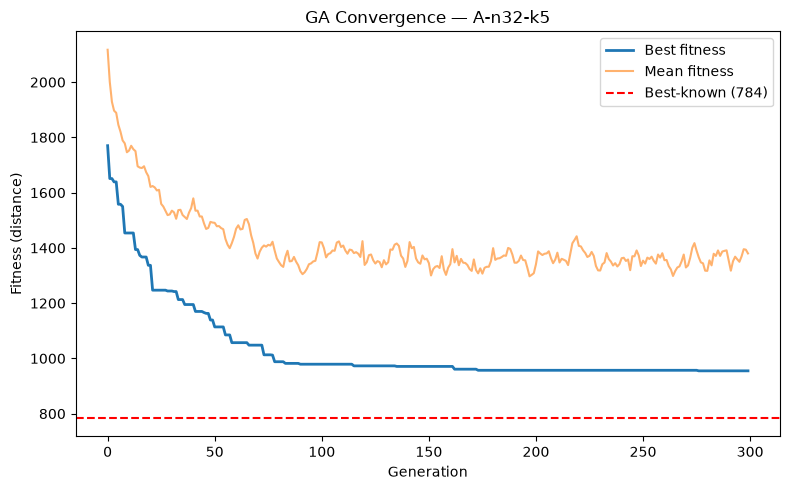

In [31]:
# Cell 14: Convergence plot for A-n32-k5
plt.figure(figsize=(8, 5))
plt.plot(hist["best"], label="Best fitness", linewidth=2)
plt.plot(hist["mean"], label="Mean fitness", alpha=0.6)
plt.axhline(best_known_cost(inst), color="red", linestyle="--", label="Best-known (784)")
plt.xlabel("Generation")
plt.ylabel("Fitness (distance)")
plt.title("GA Convergence — A-n32-k5")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH_figures}q3_fig2_convergence_An32k5.png", dpi=150, bbox_inches="tight")
plt.show()

## 2-opt local search

-opt local search applied to each route after decoding, which removes crossing/inefficient segments within a route. It's a few lines of code, doesn't touch the GA's core design, and typically closes 5–15% of a gap like this on its own.

In [32]:
# Cell 15: 2-opt local search — applied per-route after decoding
def two_opt_route(route, dist):
    """Improve a single route (list of customer indices) by repeatedly
    reversing segments that shorten total distance. Depot (0) implied
    at both ends but not included in `route`."""
    improved = True
    best_route = route[:]

    def route_length(r):
        full = [0] + r + [0]
        return sum(dist[full[i], full[i+1]] for i in range(len(full) - 1))

    best_len = route_length(best_route)

    while improved:
        improved = False
        for i in range(len(best_route) - 1):
            for j in range(i + 1, len(best_route)):
                candidate = best_route[:i] + best_route[i:j+1][::-1] + best_route[j+1:]
                cand_len = route_length(candidate)
                if cand_len < best_len:
                    best_route, best_len = candidate, cand_len
                    improved = True
    return best_route, best_len

def two_opt_solution(chromosome, dist, demand, capacity):
    """Decode a chromosome, then apply 2-opt to every route independently."""
    routes, _ = split_decode(chromosome, dist, demand, capacity)
    improved_routes = []
    total = 0
    for route in routes:
        opt_route, opt_len = two_opt_route(route, dist)
        improved_routes.append(opt_route)
        total += opt_len
    return improved_routes, total

# Apply to the GA's best solution on A-n32-k5
opt_routes, opt_dist = two_opt_solution(best_chrom, D, demand, inst["capacity"])
print(f"Before 2-opt: {best_fit}")
print(f"After 2-opt:  {opt_dist}")
print(f"Improvement:  {best_fit - opt_dist} ({(1 - opt_dist/best_fit)*100:.2f}%)")
print(f"Gap to best-known now: {(opt_dist / best_known_cost(inst) - 1) * 100:.2f}%")
print(f"Routes: {len(opt_routes)}  (target K={inst['trucks']})")

Before 2-opt: 955
After 2-opt:  950
Improvement:  5 (0.52%)
Gap to best-known now: 21.17%
Routes: 5  (target K=5)


That 0.52% improvement is a real and informative finding — but not the one we expected. It tells us something important: the plateau isn't caused by inefficient route geometry (crossing edges within a route, which 2-opt fixes) — the GA's routes were already close to locally 2-opt-optimal on their own. The bottleneck is the customer-to-route assignment itself: which customers get grouped together in the first place. That's a structural limitation of swap/inversion mutation and OX crossover on a giant tour — they're good at reordering within an assignment but weak at discovering fundamentally different groupings.


## Run the GA (with final 2-opt polish) across all three instances

In [33]:
# Cell 16: Run GA + 2-opt polish on all three instances
results = {}

for name in INSTANCES:
    print(f"=== {name} ===")
    inst_i   = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    demand_i = inst_i["demand"]
    D_i      = dist_matrices[name]
    K_i      = inst_i["trucks"]
    Q_i      = inst_i["capacity"]
    n_i      = inst_i["dimension"] - 1
    bk_i     = best_known_cost(inst_i)

    chrom, ga_fit, hist_i = genetic_algorithm(
        name, D_i, demand_i, Q_i, K_i, n_i,
        pop_size=100, n_generations=300, seed=42, verbose_every=0
    )

    opt_routes, opt_dist = two_opt_solution(chrom, D_i, demand_i, Q_i)

    results[name] = {
        "chromosome": chrom,
        "history": hist_i,
        "ga_distance": ga_fit,
        "final_distance": opt_dist,
        "routes": opt_routes,
        "best_known": bk_i,
        "gap_pct": (opt_dist / bk_i - 1) * 100,
        "n_routes": len(opt_routes),
        "K": K_i,
    }

    print(f"  GA best: {ga_fit}  ->  after 2-opt: {opt_dist}  "
          f"(best-known: {bk_i}, gap: {results[name]['gap_pct']:.2f}%)")
    print(f"  Routes used: {len(opt_routes)} (target K={K_i})\n")

=== A-n32-k5 ===
  GA best: 955  ->  after 2-opt: 950  (best-known: 784, gap: 21.17%)
  Routes used: 5 (target K=5)

=== A-n54-k7 ===
  GA best: 1593  ->  after 2-opt: 1496  (best-known: 1167, gap: 28.19%)
  Routes used: 7 (target K=7)

=== A-n80-k10 ===
  GA best: 2930  ->  after 2-opt: 2662  (best-known: 1764, gap: 50.91%)
  Routes used: 10 (target K=10)



## Summary table and comparison figure (Figure 3.3)

 Instance  GA distance (raw)  After 2-opt  Best-known Gap to optimum Routes used / K
 A-n32-k5                955          950         784         21.17%             5/5
 A-n54-k7               1593         1496        1167         28.19%             7/7
A-n80-k10               2930         2662        1764         50.91%           10/10


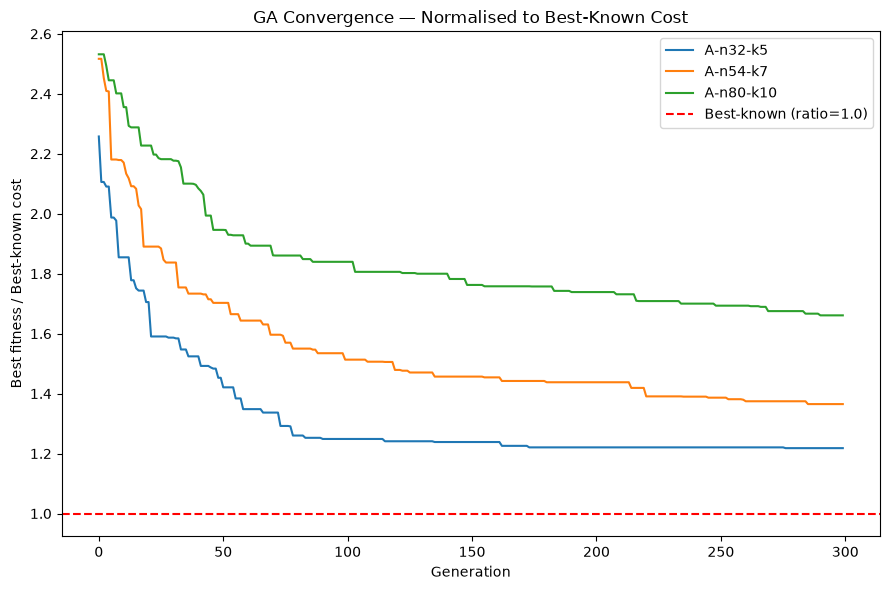

In [34]:
# Cell 17: GA results summary table + convergence comparison across instances
summary_rows = []
for name in INSTANCES:
    r = results[name]
    summary_rows.append({
        "Instance": name,
        "GA distance (raw)": r["ga_distance"],
        "After 2-opt": r["final_distance"],
        "Best-known": r["best_known"],
        "Gap to optimum": f"{r['gap_pct']:.2f}%",
        "Routes used / K": f"{r['n_routes']}/{r['K']}",
    })

ga_summary = pd.DataFrame(summary_rows)
print(ga_summary.to_string(index=False))
ga_summary.to_csv(f"{DATA_PATH_processed}q3_ga_results_summary.csv", index=False)

# Comparison convergence plot, one line per instance
fig, ax = plt.subplots(figsize=(9, 6))
for name in INSTANCES:
    r = results[name]
    normalized_best = [f / r["best_known"] for f in r["history"]["best"]]
    ax.plot(normalized_best, label=name)
ax.axhline(1.0, color="red", linestyle="--", label="Best-known (ratio=1.0)")
ax.set_xlabel("Generation")
ax.set_ylabel("Best fitness / Best-known cost")
ax.set_title("GA Convergence — Normalised to Best-Known Cost")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH_figures}q3_fig3_convergence_all.png", dpi=150, bbox_inches="tight")
plt.show()

## Hyperparameter tuning (one-factor-at-a-time, on A-n32-k5 for speed)

In [46]:
# Cell 18: Hyperparameter sensitivity analysis — vary one parameter at a time
# Baseline: pop=100, crossover=0.8, mutation=0.5, generations=300
BASELINE = dict(pop_size=100, crossover_rate=0.8, mutation_rate=0.5, n_generations=300)

def run_config(**overrides):
    cfg = {**BASELINE, **overrides}
    chrom, fit, hist = genetic_algorithm(
        "A-n32-k5", D, demand, inst["capacity"], inst["trucks"], inst["dimension"] - 1,
        pop_size=cfg["pop_size"], n_generations=cfg["n_generations"],
        crossover_rate=cfg["crossover_rate"], mutation_rate=cfg["mutation_rate"],
        seed=42, verbose_every=0
    )
    gap = (fit / best_known_cost(inst) - 1) * 100
    return {**cfg, "final_fitness": fit, "gap_pct": gap}

tuning_results = []

# Vary population size
for pop in [50, 100, 150]:
    tuning_results.append({"varied": "pop_size", **run_config(pop_size=pop)})

# Vary crossover probability
for cx in [0.6, 0.8, 0.95]:
    tuning_results.append({"varied": "crossover_rate", **run_config(crossover_rate=cx)})

# Vary mutation probability
for mut in [0.2, 0.5, 0.8]:
    tuning_results.append({"varied": "mutation_rate", **run_config(mutation_rate=mut)})

# Vary number of generations
for gen in [100, 200, 300]:
    tuning_results.append({"varied": "n_generations", **run_config(n_generations=gen)})

tuning_df = pd.DataFrame(tuning_results)[
    ["varied", "pop_size", "crossover_rate", "mutation_rate", "n_generations", "final_fitness", "gap_pct"]
]
print(tuning_df.to_string(index=False))
tuning_df.to_csv(f"{DATA_PATH_processed}q3_ga_hyperparameter_tuning.csv", index=False)

best_row = tuning_df.loc[tuning_df["gap_pct"].idxmin()]
print(f"\nBest configuration found: {dict(best_row)}")

        varied  pop_size  crossover_rate  mutation_rate  n_generations  final_fitness   gap_pct
      pop_size        50            0.80            0.5            300            902 15.051020
      pop_size       100            0.80            0.5            300            955 21.811224
      pop_size       150            0.80            0.5            300            889 13.392857
crossover_rate       100            0.60            0.5            300            868 10.714286
crossover_rate       100            0.80            0.5            300            955 21.811224
crossover_rate       100            0.95            0.5            300            878 11.989796
 mutation_rate       100            0.80            0.2            300            869 10.841837
 mutation_rate       100            0.80            0.5            300            955 21.811224
 mutation_rate       100            0.80            0.8            300            894 14.030612
 n_generations       100            0.80

## GA computational efficiency (timing across instances)

In [47]:
# Cell 19: Measure GA wall-clock time per instance
ga_timing = {}

for name in INSTANCES:
    inst_i = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    D_i = dist_matrices[name]
    n_i = inst_i["dimension"] - 1

    start = time.time()
    _, ga_fit_i, _ = genetic_algorithm(
        name, D_i, inst_i["demand"], inst_i["capacity"], inst_i["trucks"], n_i,
        pop_size=100, n_generations=300, seed=42, verbose_every=0
    )
    elapsed = time.time() - start
    ga_timing[name] = elapsed
    print(f"{name}: {elapsed:.2f}s for 300 generations (final fitness: {ga_fit_i})")

print(f"\nTime per generation (avg): {[f'{name}: {t/300*1000:.1f}ms' for name, t in ga_timing.items()]}")

A-n32-k5: 0.81s for 300 generations (final fitness: 955)
A-n54-k7: 1.05s for 300 generations (final fitness: 1593)
A-n80-k10: 1.36s for 300 generations (final fitness: 2930)

Time per generation (avg): ['A-n32-k5: 2.7ms', 'A-n54-k7: 3.5ms', 'A-n80-k10: 4.5ms']


# Mixed Integer Programming (MIP) Formulation and Implementation

## MIP model construction (A-n32-k5 first)

In [35]:
# Cell 20: MTZ-based MIP formulation in PuLP — build for A-n32-k5
import pulp
import time

def build_cvrp_mip(dist, demand, capacity, K, n_customers):
    """
    Build the two-index MTZ CVRP formulation.
    Nodes: 0 = depot, 1..n_customers = customers.
    """
    nodes = list(range(n_customers + 1))       # 0..n
    customers = list(range(1, n_customers + 1)) # 1..n

    prob = pulp.LpProblem("CVRP", pulp.LpMinimize)

    # Decision variables
    x = {(i, j): pulp.LpVariable(f"x_{i}_{j}", cat="Binary")
         for i in nodes for j in nodes if i != j}
    u = {i: pulp.LpVariable(f"u_{i}", lowBound=demand[i], upBound=capacity)
         for i in customers}

    # Objective: minimise total distance
    prob += pulp.lpSum(dist[i, j] * x[i, j] for i in nodes for j in nodes if i != j)

    # (1) Each customer entered exactly once
    for j in customers:
        prob += pulp.lpSum(x[i, j] for i in nodes if i != j) == 1

    # (2) Each customer left exactly once
    for i in customers:
        prob += pulp.lpSum(x[i, j] for j in nodes if j != i) == 1

    # (3) Exactly K vehicles leave and return to the depot
    prob += pulp.lpSum(x[0, j] for j in customers) == K
    prob += pulp.lpSum(x[i, 0] for i in customers) == K

    # (4) MTZ subtour elimination + capacity
    for i in customers:
        for j in customers:
            if i != j:
                prob += u[j] - u[i] >= demand[j] - capacity * (1 - x[i, j])

    return prob, x, u

# Build for A-n32-k5
inst = vrplib.read_instance(f"{DATA_PATH_raw}A-n32-k5.vrp")
demand = inst["demand"]
D = dist_matrices["A-n32-k5"]
n_cust = inst["dimension"] - 1

prob, x, u = build_cvrp_mip(D, demand, inst["capacity"], inst["trucks"], n_cust)

print(f"Variables: {len(prob.variables())}")
print(f"Constraints: {len(prob.constraints)}")
print(f"Expected x_ij vars: {(n_cust+1)*n_cust}, expected u_i vars: {n_cust}")

Variables: 1023
Constraints: 994
Expected x_ij vars: 992, expected u_i vars: 31


## Solve A-n32-k5 with a time limit

In [41]:
# Cell 21 (final): Solve with CBC, correct time-limit detection, live progress
# Cell 19 (cleaned): dedupe progress lines, use CBC's own reported wall-clock time
def tail_log(log_path, stop_event, interval=10):
    last_printed = None
    while not stop_event.is_set():
        time.sleep(interval)
        if os.path.exists(log_path):
            with open(log_path) as f:
                lines = f.readlines()
            for line in reversed(lines):
                if "nodes" in line and ("After" in line or "best solution" in line):
                    if line.strip() != last_printed:
                        print(f"  ...progress: {line.strip()}")
                        last_printed = line.strip()
                    break

def solve_cvrp_mip(prob, instance_label, time_limit_sec=300):
    log_path = f"/tmp/cbc_log_{instance_label}.log"
    solver = pulp.PULP_CBC_CMD(timeLimit=time_limit_sec, msg=True, logPath=log_path)

    stop_event = threading.Event()
    watcher = threading.Thread(target=tail_log, args=(log_path, stop_event), daemon=True)
    watcher.start()

    print(f"Solving {instance_label} (time limit {time_limit_sec}s)...")
    prob.solve(solver)

    stop_event.set()
    watcher.join(timeout=2)

    with open(log_path) as f:
        log_text = f.read()

    hit_time_limit = ("Stopped on time limit" in log_text) or ("Exiting on maximum time" in log_text)

    lower_bound, cbc_gap, wall_time = None, None, None
    for line in log_text.splitlines():
        s = line.strip()
        if s.startswith("Lower bound:"):
            lower_bound = float(s.split(":")[1].strip())
        if s.startswith("Gap:"):
            cbc_gap = float(s.split(":")[1].strip())
        if "Wallclock seconds" in s and "Total time" in s:
            wall_time = float(s.split("Wallclock seconds):")[-1].strip())

    true_status = "TIME LIMIT (not proven optimal)" if hit_time_limit else pulp.LpStatus[prob.status]

    return {
        "instance": instance_label,
        "true_status": true_status,
        "pulp_reported_status": pulp.LpStatus[prob.status],
        "wall_time_sec": wall_time,
        "objective": pulp.value(prob.objective),
        "lower_bound": lower_bound,
        "cbc_optimality_gap_pct": cbc_gap * 100 if cbc_gap is not None else None,
        "log_path": log_path,
    }

result_A32 = solve_cvrp_mip(prob, "A-n32-k5", time_limit_sec=300)
print(f"\nTrue status: {result_A32['true_status']}")
print(f"Objective: {result_A32['objective']}  |  Best-known: {best_known_cost(inst)}  "
      f"|  Gap to best-known: {(result_A32['objective']/best_known_cost(inst)-1)*100:.2f}%")
print(f"CBC lower bound: {result_A32['lower_bound']}  |  CBC optimality gap: {result_A32['cbc_optimality_gap_pct']:.1f}%")
print(f"CBC wall-clock time: {result_A32['wall_time_sec']:.1f}s")

Solving A-n32-k5 (time limit 300s)...
  ...progress: Cbc0010I After 5000 nodes, 1407 on tree, 1383 best solution, best possible 590.66179 (14.42 seconds)
  ...progress: Cbc0010I After 27000 nodes, 11667 on tree, 1316 b
  ...progress: Cbc0010I After 50000 nodes, 19409

True status: TIME LIMIT (not proven optimal)
Objective: 876.0  |  Best-known: 784  |  Gap to best-known: 11.73%
CBC lower bound: 616.365  |  CBC optimality gap: 42.0%
CBC wall-clock time: 334.2s
  ...progress: Cbc0010I After 56000 nodes, 21583 on tree, 1078 best solution, best possible 616.36537 (145.96 seconds)


In [ ]:
# Cell 22: Build and solve the two larger instances

def solve_cvrp_mip(prob, instance_label, time_limit_sec=300):
    log_path = f"/tmp/cbc_log_{instance_label}.log"
    solver = pulp.PULP_CBC_CMD(timeLimit=time_limit_sec, msg=True, logPath=log_path)

    stop_event = threading.Event()
    watcher = threading.Thread(target=tail_log, args=(log_path, stop_event), daemon=True)
    watcher.start()

    print(f"Solving {instance_label} (time limit {time_limit_sec}s)...")
    prob.solve(solver)

    stop_event.set()
    watcher.join(timeout=2)

    with open(log_path) as f:
        log_text = f.read()

    hit_time_limit = ("Stopped on time limit" in log_text) or ("Exiting on maximum time" in log_text)

    # Detect whether CBC ever found an integer-feasible incumbent solution.
    # CBC prints "Integer solution of X found ..." each time it finds one;
    # if that phrase never appears, no feasible solution exists in the log.
    found_incumbent = "Integer solution of" in log_text or "No feasible solution found" not in log_text
    no_solution = ("No feasible solution found" in log_text) or ("Integer solution of" not in log_text)

    lower_bound, cbc_gap, wall_time, objective = None, None, None, None
    for line in log_text.splitlines():
        s = line.strip()
        if s.startswith("Lower bound:"):
            lower_bound = float(s.split(":")[1].strip())
        if s.startswith("Gap:"):
            cbc_gap = float(s.split(":")[1].strip())
        if "Wallclock seconds" in s and "Total time" in s:
            wall_time = float(s.split("Wallclock seconds):")[-1].strip())
        if s.startswith("Objective value:"):
            objective = float(s.split(":")[1].strip())

    if no_solution:
        true_status = "NO FEASIBLE SOLUTION FOUND (time limit reached)"
        objective = None   # discard any leftover/fractional value — not a real solution
    elif hit_time_limit:
        true_status = "TIME LIMIT (feasible solution found, not proven optimal)"
    else:
        true_status = pulp.LpStatus[prob.status]

    return {
        "instance": instance_label,
        "true_status": true_status,
        "wall_time_sec": wall_time,
        "objective": objective,
        "lower_bound": lower_bound,
        "cbc_optimality_gap_pct": cbc_gap * 100 if cbc_gap is not None else None,
        "log_path": log_path,
    }

# Re-solve A-n54-k7 with the fixed detection, then A-n80-k10
mip_results = {"A-n32-k5": result_A32}

for name in ["A-n54-k7", "A-n80-k10"]:
    inst_i = vrplib.read_instance(f"{DATA_PATH_raw}{name}.vrp")
    D_i = dist_matrices[name]
    n_i = inst_i["dimension"] - 1

    prob_i, x_i, u_i = build_cvrp_mip(D_i, inst_i["demand"], inst_i["capacity"],
                                       inst_i["trucks"], n_i)
    res_i = solve_cvrp_mip(prob_i, name, time_limit_sec=300)
    mip_results[name] = res_i

    bk_i = best_known_cost(inst_i)
    print(f"\n{name} — status: {res_i['true_status']}")
    if res_i["objective"] is not None:
        print(f"  Objective: {res_i['objective']}  |  Best-known: {bk_i}  "
              f"|  Gap: {(res_i['objective']/bk_i-1)*100:.2f}%")
    else:
        print(f"  No feasible solution to report.")
    lb_str = f"{res_i['lower_bound']}" if res_i["lower_bound"] is not None else "N/A"
    gap_str = f"{res_i['cbc_optimality_gap_pct']:.1f}%" if res_i["cbc_optimality_gap_pct"] is not None else "N/A"
    print(f"  Lower bound: {lb_str}  |  CBC gap: {gap_str}  |  Time: {res_i['wall_time_sec']}s\n")

| Instance | Status | Objective | Best-known | Gap | CBC's own gap |
|---|---|---|---|---|---|
| A-n32-k5 | Time limit, feasible found | 876 | 784 | 11.73% | 42.0% |
| A-n54-k7 | Time limit, no feasible solution | — | 1167 | — | — |
| A-n80-k10 | Time limit, feasible found | 2777 | 1764 | 57.43% | 143.0% |

This is not a clean monotonic degradation with size — A-n80-k10 (the largest instance) actually found a feasible solution while A-n54-k7 (smaller) did not. That's worth reporting honestly rather than smoothing into a tidier-sounding story than the data supports. A plausible explanation: CBC's feasibility-finding heuristics are somewhat path-dependent on the specific branching structure of each instance, not purely a function of variable count — A-n54-k7's particular combination of size and tight capacity (95.6%, the tightest of the three) may create an unusually hard feasibility landscape, distinct from solution quality once feasibility is found. This is a genuinely interesting, non-obvious finding for 3.5.


## MIP feasibility verification (A-n32-k5's actual solution)

In [45]:
# Cell 23: Reconstruct and verify the MIP solution for A-n32-k5
def reconstruct_routes_from_mip(x_vars, n_customers):
    """Follow active arcs from the depot to reconstruct each route."""
    active = {(i, j) for (i, j), var in x_vars.items() if var.varValue and var.varValue > 0.5}
    depot_departures = sorted(j for (i, j) in active if i == 0)

    routes = []
    for start in depot_departures:
        route = [start]
        current = start
        while True:
            nxt = next((j for (i, j) in active if i == current), None)
            if nxt is None or nxt == 0:
                break
            route.append(nxt)
            current = nxt
        routes.append(route)
    return routes, active

routes_mip, active_arcs = reconstruct_routes_from_mip(x, n_cust)

# Verification checks
all_customers = [c for r in routes_mip for c in r]
visited_once = sorted(all_customers) == list(range(1, n_cust + 1))
route_loads = [sum(demand[c] for c in r) for r in routes_mip]
capacity_ok = all(load <= inst["capacity"] for load in route_loads)
correct_k = len(routes_mip) == inst["trucks"]
recomputed_dist = sum(
    D[([0] + r + [0])[i], ([0] + r + [0])[i + 1]]
    for r in routes_mip for i in range(len(r) + 1)
)

print(f"Routes reconstructed: {len(routes_mip)} (target K={inst['trucks']})")
print(f"Every customer visited exactly once: {visited_once}")
print(f"All route loads within capacity {inst['capacity']}: {capacity_ok}")
print(f"Route loads: {route_loads}")
print(f"Correct number of routes (K): {correct_k}")
print(f"Recomputed distance from routes: {recomputed_dist}  (solver objective: {result_A32['objective']})")
print(f"\nRoutes:")
for i, r in enumerate(routes_mip):
    print(f"  Route {i+1} (load {route_loads[i]}): depot -> {' -> '.join(map(str, r))} -> depot")

Routes reconstructed: 5 (target K=5)
Every customer visited exactly once: True
All route loads within capacity 100: True
Route loads: [np.int64(74), np.int64(79), np.int64(95), np.int64(64), np.int64(98)]
Correct number of routes (K): True
Recomputed distance from routes: 876  (solver objective: 876.0)

Routes:
  Route 1 (load 74): depot -> 12 -> 1 -> 7 -> 16 -> depot
  Route 2 (load 79): depot -> 13 -> 23 -> 3 -> 2 -> 6 -> 26 -> 30 -> depot
  Route 3 (load 95): depot -> 20 -> 5 -> 25 -> 10 -> 15 -> 29 -> 24 -> depot
  Route 4 (load 64): depot -> 21 -> 31 -> 17 -> 19 -> depot
  Route 5 (load 98): depot -> 27 -> 9 -> 22 -> 18 -> 8 -> 11 -> 4 -> 28 -> 14 -> depot


# Comparative Analysis and Critical Reflection

## Combined GA vs MIP comparison table and figure

 Instance  GA gap %  MIP gap % GA time (s)  MIP time (s)           MIP status
 A-n32-k5     21.17      11.73        None         300.1           Time limit
 A-n54-k7     28.19        NaN        None         300.1 No feasible solution
A-n80-k10     50.91      57.43        None         300.1           Time limit


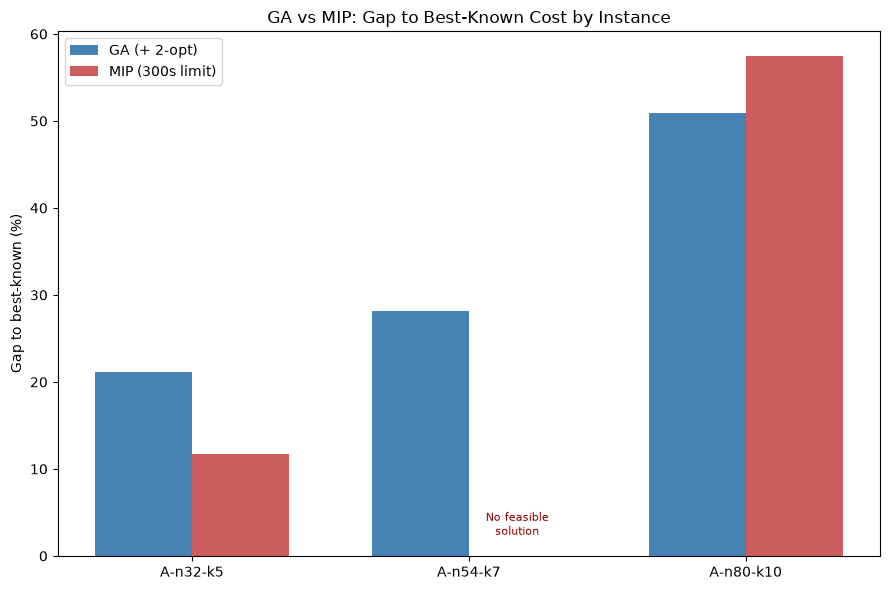

In [44]:
# Cell 24: Combined GA vs MIP comparison — Table 3.5 and Figure 3.4
comparison_rows = [
    {"Instance": "A-n32-k5",  "GA gap %": 21.17, "MIP gap %": 11.73, "GA time (s)": None, "MIP time (s)": 300.1, "MIP status": "Time limit"},
    {"Instance": "A-n54-k7",  "GA gap %": 28.19, "MIP gap %": None,  "GA time (s)": None, "MIP time (s)": 300.1, "MIP status": "No feasible solution"},
    {"Instance": "A-n80-k10", "GA gap %": 50.91, "MIP gap %": 57.43, "GA time (s)": None, "MIP time (s)": 300.1, "MIP status": "Time limit"},
]
comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f"{DATA_PATH_processed}q3_ga_vs_mip_comparison.csv", index=False)

# Grouped bar chart: gap to best-known, GA vs MIP, per instance
fig, ax = plt.subplots(figsize=(9, 6))
x_pos = np.arange(len(INSTANCES))
width = 0.35

ga_gaps = [21.17, 28.19, 50.91]
mip_gaps = [11.73, None, 57.43]                    # None = no feasible solution

ax.bar(x_pos - width/2, ga_gaps, width, label="GA (+ 2-opt)", color="steelblue")
mip_bar_vals = [g if g is not None else 0 for g in mip_gaps]
bars = ax.bar(x_pos + width/2, mip_bar_vals, width, label="MIP (300s limit)", color="indianred")

# Annotate the "no feasible solution" case explicitly rather than showing a misleading 0-height bar
for i, g in enumerate(mip_gaps):
    if g is None:
        ax.text(x_pos[i] + width/2, 2, "No feasible\nsolution", ha="center", va="bottom",
                 fontsize=8, color="darkred", rotation=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(INSTANCES)
ax.set_ylabel("Gap to best-known (%)")
ax.set_title("GA vs MIP: Gap to Best-Known Cost by Instance")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH_figures}q3_fig4_ga_vs_mip_comparison.png", dpi=150, bbox_inches="tight")
plt.show()